# Model Training

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

## 2. Read Data

In [34]:
df_hourly = pd.read_csv('../data/processed/hourly_features.csv')

df_hourly['timestamp'] = pd.to_datetime(df_hourly['timestamp'])

df_hourly = df_hourly.sort_values('timestamp')

In [35]:
target = 'demand'

features = ['hour', 'hour_cos', 'hour_sin', 'day_of_week', 'is_weekend', 'lag_1', 'lag_24', 'rolling_24']

X = df_hourly[features]
y = df_hourly[target]

## 3. Split Data

In [36]:
split_idx = int(len(df_hourly) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

## 4. Train Models

In [37]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 5. Predict & Evaluation

In [38]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5.058470048063689
RMSE: 8.804302807941989


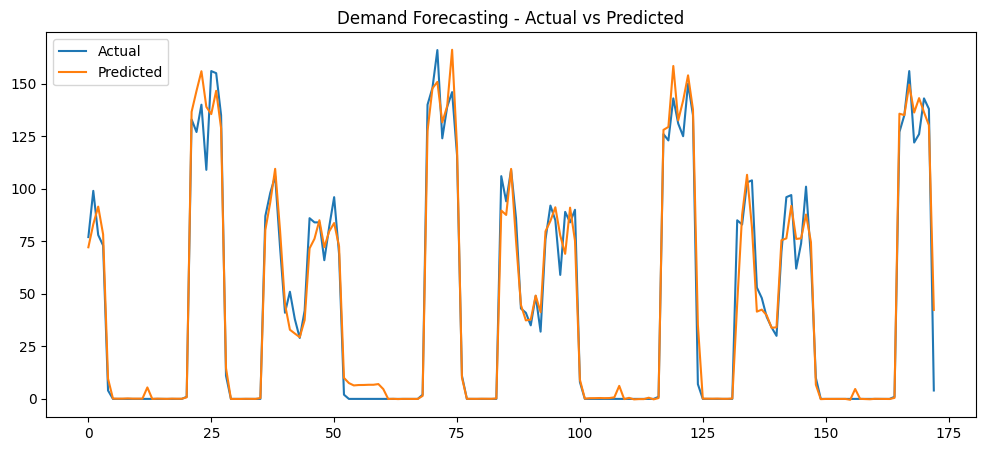

In [39]:
plt.figure(figsize=(12,5))
sns.lineplot(y_test.values, label="Actual")
sns.lineplot(preds, label="Predicted")
plt.legend()
plt.title("Demand Forecasting - Actual vs Predicted")
plt.show()

In [40]:
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

print(importance)

hour           0.496815
hour_sin       0.186354
hour_cos       0.104530
lag_1          0.103674
rolling_24     0.064719
lag_24         0.038890
day_of_week    0.002912
is_weekend     0.002106
dtype: float32


## 6. Save Model